In [25]:
import torch, torchvision
print("torch:", torch.__version__)
print("cuda available:", torch.cuda.is_available())

torch: 2.9.0+cu126
cuda available: True


In [26]:
!pip -q install scikit-learn matplotlib tqdm

In [27]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:
!ls /content

drive  sample_data


In [9]:
!ls drive

MyDrive


In [10]:
!ls "/content/drive/My Drive/CVNL"

fgvc-aircraft-2013b


In [11]:
!ls "/content/drive/My Drive/CVNL/fgvc-aircraft-2013b"


fgvc-aircraft-2013b


In [12]:
DATA_ROOT = "/content/drive/My Drive/CVNL/fgvc-aircraft-2013b/fgvc-aircraft-2013b/data"
!ls "$DATA_ROOT"


families.txt			  images_manufacturer_val.txt
images				  images_test.txt
images_box.txt			  images_train.txt
images_family_test.txt		  images_val.txt
images_family_train.txt		  images_variant_test.txt
images_family_trainval.txt	  images_variant_train.txt
images_family_val.txt		  images_variant_trainval.txt
images_manufacturer_test.txt	  images_variant_val.txt
images_manufacturer_train.txt	  manufacturers.txt
images_manufacturer_trainval.txt  variants.txt


In [13]:
!ls "$DATA_ROOT/images" | head -n 5

0034309.jpg
0034958.jpg
0037511.jpg
0037512.jpg
0038598.jpg


In [14]:
DATA_ROOT = "/content/drive/My Drive/CVNL/fgvc-aircraft-2013b/fgvc-aircraft-2013b/data"

import os
assert os.path.exists(DATA_ROOT), f"DATA_ROOT not found: {DATA_ROOT}"
assert os.path.exists(os.path.join(DATA_ROOT, "images")), "images/ folder missing"
print("✅ DATA_ROOT looks correct:", DATA_ROOT)
print("Sample images:", len(os.listdir(os.path.join(DATA_ROOT, "images"))))


✅ DATA_ROOT looks correct: /content/drive/My Drive/CVNL/fgvc-aircraft-2013b/fgvc-aircraft-2013b/data
Sample images: 10000


In [15]:
import os
from PIL import Image
from torch.utils.data import Dataset
from torchvision import transforms

def read_lines(path):
    with open(path, "r", encoding="utf-8") as f:
        return [line.strip() for line in f if line.strip()]

def parse_labeled_file(path):
    # format: "<img_id> <label...>"
    lines = read_lines(path)
    img_ids, labels = [], []
    for line in lines:
        parts = line.split(" ")
        img_id = parts[0]
        label = " ".join(parts[1:])
        img_ids.append(img_id)
        labels.append(label)
    return img_ids, labels

def load_bboxes(path):
    # images_box.txt: img_id xmin ymin xmax ymax (1-indexed)
    bboxes = {}
    for line in read_lines(path):
        parts = line.split()
        img_id = parts[0]
        xmin, ymin, xmax, ymax = map(int, parts[1:])
        bboxes[img_id] = (xmin, ymin, xmax, ymax)
    return bboxes

class FGVCAircraft(Dataset):
    def __init__(self, root, level="family", split="train",
                 transform=None, use_bbox=False, remove_banner=True):
        self.root = root
        self.level = level
        self.split = split
        self.transform = transform
        self.use_bbox = use_bbox
        self.remove_banner = remove_banner

        self.images_dir = os.path.join(root, "images")
        self.bboxes = load_bboxes(os.path.join(root, "images_box.txt"))

        label_file = os.path.join(root, f"images_{level}_{split}.txt")
        self.img_ids, self.labels_text = parse_labeled_file(label_file)

        unique_labels = sorted(set(self.labels_text))
        self.label_to_idx = {lab: i for i, lab in enumerate(unique_labels)}
        self.idx_to_label = {i: lab for lab, i in self.label_to_idx.items()}
        self.labels = [self.label_to_idx[lab] for lab in self.labels_text]

    def __len__(self):
        return len(self.img_ids)

    def __getitem__(self, idx):
        img_id = self.img_ids[idx]
        y = self.labels[idx]
        img_path = os.path.join(self.images_dir, f"{img_id}.jpg")

        img = Image.open(img_path).convert("RGB")

        # remove 20px banner at bottom (dataset note)
        if self.remove_banner:
            w, h = img.size
            img = img.crop((0, 0, w, max(1, h - 20)))

        # optional bbox crop
        if self.use_bbox and img_id in self.bboxes:
            xmin, ymin, xmax, ymax = self.bboxes[img_id]
            xmin -= 1; ymin -= 1  # convert to 0-index for PIL
            img = img.crop((xmin, ymin, xmax, ymax))

        if self.transform:
            img = self.transform(img)

        return img, y


In [16]:
import torch
import numpy as np
from tqdm import tqdm
from sklearn.metrics import classification_report, confusion_matrix

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

def collect_preds(model, loader):
    model.eval()
    all_preds, all_true = [], []
    with torch.no_grad():
        for x, y in tqdm(loader, leave=False):
            x = x.to(device)
            logits = model(x)
            preds = logits.argmax(dim=1).cpu().numpy()
            all_preds.append(preds)
            all_true.append(y.numpy())
    return np.concatenate(all_true), np.concatenate(all_preds)

def evaluate_and_print(model, loader, idx_to_label, max_labels_for_report=30):
    y_true, y_pred = collect_preds(model, loader)
    acc = (y_true == y_pred).mean()
    print(f"✅ Accuracy: {acc:.4f}")

    # Full report can be huge (70/102 classes). We still compute it,
    # but you may choose to paste only macro avg into slides.
    target_names = [idx_to_label[i] for i in range(len(idx_to_label))]
    report = classification_report(y_true, y_pred, target_names=target_names, digits=4, output_dict=True)
    print("Macro avg F1:", report["macro avg"]["f1-score"])
    print("Weighted avg F1:", report["weighted avg"]["f1-score"])

    cm = confusion_matrix(y_true, y_pred)
    return acc, report, cm

def top_misclassifications(cm, idx_to_label, topk=15):
    cm_off = cm.copy()
    np.fill_diagonal(cm_off, 0)

    pairs = []
    for i in range(cm_off.shape[0]):
        for j in range(cm_off.shape[1]):
            if cm_off[i, j] > 0:
                pairs.append((cm_off[i, j], i, j))
    pairs.sort(reverse=True)

    print(f"Top {topk} misclassifications:")
    for count, i, j in pairs[:topk]:
        print(f"{count:4d} | true: {idx_to_label[i]}  -> pred: {idx_to_label[j]}")

device: cuda


In [18]:
import os
import json
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np

from PIL import Image
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from sklearn.metrics import classification_report, confusion_matrix

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# CHANGE THIS ONLY IF YOUR PATH IS DIFFERENT
DATA_ROOT = "/content/drive/My Drive/CVNL/fgvc-aircraft-2013b/fgvc-aircraft-2013b/data"

LEVEL = "family"  # use family (recommended)


Using device: cuda


In [19]:
train_tf_v1 = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(0.3),
    transforms.ToTensor(),
])

test_tf_v1 = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
])

train_ds_v1 = FGVCAircraft(DATA_ROOT, LEVEL, "train", train_tf_v1, use_bbox=False)
val_ds_v1   = FGVCAircraft(DATA_ROOT, LEVEL, "val", test_tf_v1, use_bbox=False)
test_ds_v1  = FGVCAircraft(DATA_ROOT, LEVEL, "test", test_tf_v1, use_bbox=False)

train_loader_v1 = DataLoader(train_ds_v1, batch_size=32, shuffle=True)
val_loader_v1   = DataLoader(val_ds_v1, batch_size=32)
test_loader_v1  = DataLoader(test_ds_v1, batch_size=32)

num_classes = len(train_ds_v1.label_to_idx)


In [20]:
class SimpleCNN(nn.Module):
    def __init__(self, n):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Flatten(),
            nn.Linear(128*16*16, 256), nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, n)
        )

    def forward(self, x):
        return self.net(x)

model_v1 = SimpleCNN(num_classes).to(device)


In [21]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_v1.parameters(), lr=1e-3)

EPOCHS_V1 = 5

for epoch in range(EPOCHS_V1):
    model_v1.train()
    correct, total = 0, 0

    for x, y in tqdm(train_loader_v1):
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        out = model_v1(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()

        correct += (out.argmax(1) == y).sum().item()
        total += y.size(0)

    print(f"[V1] Epoch {epoch+1}/{EPOCHS_V1} - Train Acc: {correct/total:.4f}")


100%|██████████| 105/105 [32:06<00:00, 18.35s/it]


[V1] Epoch 1/5 - Train Acc: 0.0786


100%|██████████| 105/105 [00:56<00:00,  1.86it/s]


[V1] Epoch 2/5 - Train Acc: 0.0843


100%|██████████| 105/105 [00:56<00:00,  1.86it/s]


[V1] Epoch 3/5 - Train Acc: 0.1158


100%|██████████| 105/105 [00:56<00:00,  1.87it/s]


[V1] Epoch 4/5 - Train Acc: 0.1785


100%|██████████| 105/105 [00:56<00:00,  1.87it/s]

[V1] Epoch 5/5 - Train Acc: 0.2576


VERSION 2 — RESNET18 (8 EPOCHS)
What Version 2 improves

224×224 images

Normalisation

Bounding box crop

Pretrained ResNet18

8 epochs

In [22]:
train_tf_v2 = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406], [0.229,0.224,0.225]),
])

test_tf_v2 = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406], [0.229,0.224,0.225]),
])

train_ds_v2 = FGVCAircraft(DATA_ROOT, LEVEL, "train", train_tf_v2, use_bbox=True)
val_ds_v2   = FGVCAircraft(DATA_ROOT, LEVEL, "val", test_tf_v2, use_bbox=True)

train_loader_v2 = DataLoader(train_ds_v2, batch_size=32, shuffle=True)
val_loader_v2   = DataLoader(val_ds_v2, batch_size=32)


In [23]:
model_v2 = models.resnet18(pretrained=True)
model_v2.fc = nn.Linear(model_v2.fc.in_features, num_classes)
model_v2 = model_v2.to(device)

optimizer = optim.Adam(model_v2.parameters(), lr=1e-4)
criterion = nn.CrossEntropyLoss()


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 94.5MB/s]


In [24]:
EPOCHS_V2 = 8

for epoch in range(EPOCHS_V2):
    model_v2.train()
    correct, total = 0, 0

    for x, y in tqdm(train_loader_v2):
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        out = model_v2(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()

        correct += (out.argmax(1) == y).sum().item()
        total += y.size(0)

    print(f"[V2] Epoch {epoch+1}/{EPOCHS_V2} - Train Acc: {correct/total:.4f}")


100%|██████████| 105/105 [01:02<00:00,  1.67it/s]


[V2] Epoch 1/8 - Train Acc: 0.2702


100%|██████████| 105/105 [00:59<00:00,  1.77it/s]


[V2] Epoch 2/8 - Train Acc: 0.7184


100%|██████████| 105/105 [00:59<00:00,  1.76it/s]


...

[V2] Epoch 6/8 - Train Acc: 0.9955


100%|██████████| 105/105 [00:59<00:00,  1.76it/s]


[V2] Epoch 7/8 - Train Acc: 0.9967


100%|██████████| 105/105 [01:02<00:00,  1.69it/s]

[V2] Epoch 8/8 - Train Acc: 0.9988


In [28]:
model_v3 = models.resnet18(pretrained=True)
model_v3.fc = nn.Linear(model_v3.fc.in_features, num_classes)
model_v3 = model_v3.to(device)

# Freeze backbone
for name, param in model_v3.named_parameters():
    if not name.startswith("fc"):
        param.requires_grad = False

optimizer = optim.Adam(filter(lambda p: p.requires_grad, model_v3.parameters()), lr=1e-4)
criterion = nn.CrossEntropyLoss()


In [29]:
EPOCHS_V3 = 15

for epoch in range(EPOCHS_V3):
    # Unfreeze after 3 epochs
    if epoch == 3:
        for param in model_v3.parameters():
            param.requires_grad = True
        optimizer = optim.Adam(model_v3.parameters(), lr=3e-5)
        print("Unfroze backbone")

    model_v3.train()
    correct, total = 0, 0

    for x, y in tqdm(train_loader_v2):
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        out = model_v3(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()

        correct += (out.argmax(1) == y).sum().item()
        total += y.size(0)

    print(f"[V3] Epoch {epoch+1}/{EPOCHS_V3} - Train Acc: {correct/total:.4f}")


100%|██████████| 105/105 [01:01<00:00,  1.71it/s]


[V3] Epoch 1/15 - Train Acc: 0.0510


100%|██████████| 105/105 [00:59<00:00,  1.76it/s]


[V3] Epoch 2/15 - Train Acc: 0.0807


100%|██████████| 105/105 [00:59<00:00,  1.76it/s]


...

[V3] Epoch 13/15 - Train Acc: 0.9913


100%|██████████| 105/105 [01:01<00:00,  1.72it/s]


[V3] Epoch 14/15 - Train Acc: 0.9970


100%|██████████| 105/105 [01:02<00:00,  1.67it/s]

[V3] Epoch 15/15 - Train Acc: 0.9985


In [30]:
train_ds_map = FGVCAircraft(DATA_ROOT, LEVEL, "train", train_tf_v2, use_bbox=True)

label_to_idx = train_ds_map.label_to_idx
idx_to_label = train_ds_map.idx_to_label
num_classes = len(label_to_idx)

# 2) Helper: build dataset using the SAME mapping
class FGVCAircraftMapped(FGVCAircraft):
    def __init__(self, root, level, split, transform, use_bbox, label_to_idx, idx_to_label):
        super().__init__(root, level, split, transform, use_bbox)
        # override mapping using the provided mapping
        self.label_to_idx = label_to_idx
        self.idx_to_label = idx_to_label
        # re-encode labels based on the shared mapping
        # note: labels_text not stored in base class, so we re-parse
        _, labels = parse_labeled_file(os.path.join(root, f"images_{level}_{split}.txt"))
        self.labels = [self.label_to_idx[l] for l in labels]

val_ds_m  = FGVCAircraftMapped(DATA_ROOT, LEVEL, "val",  test_tf_v2, use_bbox=True,
                               label_to_idx=label_to_idx, idx_to_label=idx_to_label)
test_ds_m = FGVCAircraftMapped(DATA_ROOT, LEVEL, "test", test_tf_v2, use_bbox=True,
                               label_to_idx=label_to_idx, idx_to_label=idx_to_label)

val_loader_m  = DataLoader(val_ds_m, batch_size=32, shuffle=False)
test_loader_m = DataLoader(test_ds_m, batch_size=32, shuffle=False)

print("✅ Shared label mapping applied. num_classes =", num_classes)

✅ Shared label mapping applied. num_classes = 70


In [31]:
from torch.cuda.amp import autocast, GradScaler

def train_with_val(model, train_loader, val_loader, epochs,
                   optimizer, criterion, save_path,
                   scheduler=None, unfreeze_at_epoch=None, fine_tune_lr=3e-5):

    scaler = GradScaler(enabled=(device.type == "cuda"))
    best_val_acc = -1.0

    for epoch in range(1, epochs + 1):
        # Optional: unfreeze backbone at a chosen epoch (for V3)
        if unfreeze_at_epoch is not None and epoch == unfreeze_at_epoch:
            for p in model.parameters():
                p.requires_grad = True
            optimizer = optim.Adam(model.parameters(), lr=fine_tune_lr)
            print(f"✅ Unfroze backbone at epoch {epoch}, LR -> {fine_tune_lr}")

        # --- Train ---
        model.train()
        train_correct, train_total, train_loss_sum = 0, 0, 0.0

        for x, y in tqdm(train_loader, leave=False):
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()

            with autocast(enabled=(device.type == "cuda")):
                out = model(x)
                loss = criterion(out, y)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            train_loss_sum += loss.item() * x.size(0)
            train_correct += (out.argmax(1) == y).sum().item()
            train_total += y.size(0)

        train_acc = train_correct / train_total
        train_loss = train_loss_sum / train_total

        # --- Validate ---
        model.eval()
        val_correct, val_total, val_loss_sum = 0, 0, 0.0
        with torch.no_grad():
            for x, y in tqdm(val_loader, leave=False):
                x, y = x.to(device), y.to(device)
                out = model(x)
                loss = criterion(out, y)
                val_loss_sum += loss.item() * x.size(0)
                val_correct += (out.argmax(1) == y).sum().item()
                val_total += y.size(0)

        val_acc = val_correct / val_total
        val_loss = val_loss_sum / val_total

        if scheduler is not None:
            scheduler.step()

        print(f"Epoch {epoch}/{epochs} | "
              f"train loss {train_loss:.4f} acc {train_acc:.4f} | "
              f"val loss {val_loss:.4f} acc {val_acc:.4f}")

        # Save best
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), save_path)
            print("✅ Saved BEST model to:", save_path, "| best_val_acc:", best_val_acc)

    return best_val_acc


In [32]:
# Build V3 model (ResNet18 pretrained)
model_v3 = models.resnet18(pretrained=True)
model_v3.fc = nn.Linear(model_v3.fc.in_features, num_classes)
model_v3 = model_v3.to(device)

# Start by freezing backbone (train classifier head first)
for name, param in model_v3.named_parameters():
    if not name.startswith("fc"):
        param.requires_grad = False

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model_v3.parameters()), lr=1e-4)

# Scheduler helps convergence (simple + safe)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=4, gamma=0.5)

EPOCHS_V3 = 15
SAVE_V3 = "/content/best_v3_resnet18_family.pth"

best_v3 = train_with_val(
    model=model_v3,
    train_loader=train_loader_v2,   # your V2 loaders are fine for training
    val_loader=val_loader_m,        # mapped val loader (correct labels)
    epochs=EPOCHS_V3,
    optimizer=optimizer,
    criterion=criterion,
    save_path=SAVE_V3,
    scheduler=scheduler,
    unfreeze_at_epoch=4,            # unfreeze from epoch 4 onwards
    fine_tune_lr=3e-5
)

print("✅ Finished V3. Best val acc:", best_v3)


/tmp/ipython-input-258576131.py:7: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=(device.type == "cuda"))
  0%|          | 0/105 [00:00<?, ?it/s]/tmp/ipython-input-258576131.py:26: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(device.type == "cuda")):


Epoch 1/15 | train loss 4.1906 acc 0.0552 | val loss 4.0516 acc 0.0663
✅ Saved BEST model to: /content/best_v3_resnet18_family.pth | best_val_acc: 0.0663066306630663


Epoch 2/15 | train loss 3.9732 acc 0.0810 | val loss 3.9220 acc 0.0876
✅ Saved BEST model to: /content/best_v3_resnet18_family.pth | best_val_acc: 0.08760876087608761


Epoch 3/15 | train loss 3.8278 acc 0.0882 | val loss 3.7975 acc 0.0966
✅ Saved BEST model to: /content/best_v3_resnet18_family.pth | best_val_acc: 0.0966096609660966
✅ Unfroze backbone at epoch 4, LR -> 3e-05


Epoch 4/15 | train loss 3.3398 acc 0.2049 | val loss 2.9245 acc 0.3315
✅ Saved BEST model to: /content/best_v3_resnet18_family.pth | best_val_acc: 0.3315331533153315


...

Epoch 11/15 | train loss 0.5151 acc 0.9754 | val loss 1.0088 acc 0.8044
✅ Saved BEST model to: /content/best_v3_resnet18_family.pth | best_val_acc: 0.8043804380438044


Epoch 12/15 | train loss 0.4036 acc 0.9844 | val loss 0.9368 acc 0.8227
✅ Saved BEST model to: /content/best_v3_resnet18_family.pth | best_val_acc: 0.8226822682268227


Epoch 13/15 | train loss 0.3033 acc 0.9910 | val loss 0.8874 acc 0.8254
✅ Saved BEST model to: /content/best_v3_resnet18_family.pth | best_val_acc: 0.8253825382538253


Epoch 14/15 | train loss 0.2344 acc 0.9967 | val loss 0.8310 acc 0.8317
✅ Saved BEST model to: /content/best_v3_resnet18_family.pth | best_val_acc: 0.8316831683168316


Epoch 15/15 | train loss 0.1878 acc 0.9967 | val loss 0.7969 acc 0.8326
✅ Saved BEST model to: /content/best_v3_resnet18_family.pth | best_val_acc: 0.8325832583258326
✅ Finished V3. Best val acc: 0.8325832583258326


Test Accuracy: 0.843084308430843
                     precision    recall  f1-score   support

               A300     0.6818    0.4545    0.5455        33
               A310     0.6333    0.5758    0.6032        33
               A320     0.8592    0.9104    0.8841       134
               A330     0.7966    0.7121    0.7520        66
               A340     0.8264    0.8881    0.8561       134
               A380     0.8462    0.6667    0.7458        33
             ATR-42     0.7812    0.7576    0.7692        33
             ATR-72     0.8438    0.7941    0.8182        34
              An-12     0.8158    0.9394    0.8732        33
            BAE 146     1.0000    0.9552    0.9771        67
            BAE-125     0.9355    0.8788    0.9062        33
    Beechcraft 1900     0.8571    0.9091    0.8824        33
         Boeing 707     0.5938    0.5758    0.5846        33
         Boeing 717     0.5946    0.6471    0.6197        34
         Boeing 727     1.0000    0.8182    0.9000 

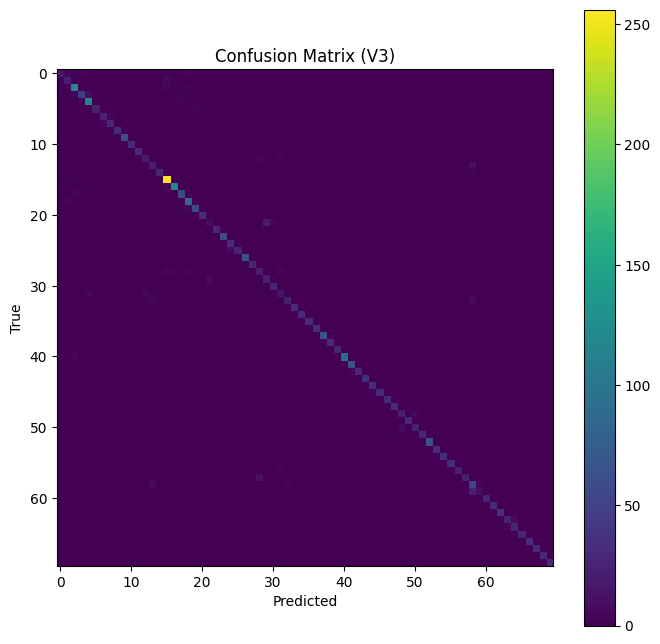

In [33]:
import matplotlib.pyplot as plt

def evaluate_full(model, loader, idx_to_label):
    model.eval()
    y_true, y_pred = [], []

    with torch.no_grad():
        for x, y in tqdm(loader, leave=False):
            x = x.to(device)
            out = model(x)
            pred = out.argmax(1).cpu().numpy()
            y_pred.append(pred)
            y_true.append(y.numpy())

    y_true = np.concatenate(y_true)
    y_pred = np.concatenate(y_pred)

    acc = (y_true == y_pred).mean()
    print("Test Accuracy:", acc)

    names = [idx_to_label[i] for i in range(len(idx_to_label))]
    print(classification_report(y_true, y_pred, target_names=names, digits=4))

    cm = confusion_matrix(y_true, y_pred)
    return acc, cm, y_true, y_pred

# Load best V3 then evaluate on TEST
model_v3.load_state_dict(torch.load(SAVE_V3, map_location=device))

acc_v3, cm_v3, y_true, y_pred = evaluate_full(model_v3, test_loader_m, idx_to_label)

plt.figure(figsize=(8,8))
plt.imshow(cm_v3, interpolation="nearest")
plt.title("Confusion Matrix (V3)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.colorbar()
plt.show()


In [34]:
cm_off = cm_v3.copy()
np.fill_diagonal(cm_off, 0)

pairs = []
for i in range(cm_off.shape[0]):
    for j in range(cm_off.shape[1]):
        if cm_off[i, j] > 0:
            pairs.append((cm_off[i, j], i, j))

pairs.sort(reverse=True)

print("Top 10 misclassifications:")
for count, i, j in pairs[:10]:
    print(f"{count:4d} | true: {idx_to_label[i]} -> pred: {idx_to_label[j]}")


Top 10 misclassifications:
  21 | true: MD-90 -> pred: MD-80
  18 | true: C-47 -> pred: DC-3
  11 | true: MD-11 -> pred: DC-10
   9 | true: Boeing 717 -> pred: MD-80
   9 | true: A330 -> pred: A340
   7 | true: Fokker 70 -> pred: Fokker 100
   6 | true: Saab 2000 -> pred: Saab 340
   6 | true: MD-80 -> pred: Boeing 717
   6 | true: DC-9 -> pred: MD-80
   6 | true: DC-3 -> pred: C-47


In [35]:
# Save label mapping for demo script later
LABELS_PATH = "/content/labels_family.json"
with open(LABELS_PATH, "w", encoding="utf-8") as f:
    json.dump({"level": LEVEL, "label_to_idx": label_to_idx}, f, ensure_ascii=False, indent=2)

print("Saved labels:", LABELS_PATH)
print("Saved model:", SAVE_V3)

from google.colab import files
files.download(LABELS_PATH)
files.download(SAVE_V3)


Saved labels: /content/labels_family.json
Saved model: /content/best_v3_resnet18_family.pth


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>